In [26]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
%matplotlib inline 

In [27]:
bindingEnergy_df = pd.read_csv("nndc_nudat_data_export.csv", usecols = ["z", "n", "bindingEnergy"])

In [28]:
''' Creating new columns for mass number and placing them between existing columns. '''

bindingEnergy_df.insert(2, "A", bindingEnergy_df['z'] + bindingEnergy_df['n'])
bindingEnergy_df.insert(3, 'x', (bindingEnergy_df['A'])**(-1.0/3.0))

In [29]:
bindingEnergy_df

,z,n,A,x,bindingEnergy
0,0,1,1,1.000000,0.0
1,1,2,3,0.693361,2820.0
2,1,3,4,0.629961,1720.0
3,1,4,5,0.584804,1330.0
4,1,5,6,0.550321,961.0
...,...,...,...,...,...
6339,116,177,293,0.150560,7110.0
6340,117,176,293,0.150560,7090.0
6341,117,177,294,0.150390,7090.0
6342,118,176,294,0.150390,7070.0


In [30]:
M = np.array([[-1.0/3, 1], [-1.0/4, 1], [-1.0/5, 1]])
b = np.array([8000, 8500, 8800])

M_T = M.T 
M_T_M = M_T @ M 

inverse = np.linalg.inv(M_T_M)

product = M_T @ b 
xp = inverse @ product  

print(xp)

xp_, residuals, rank, singular_values = np.linalg.lstsq(M, b, rcond = None)
print(xp_[0], xp_[1])



[ 6000. 10000.]
6000.000000000021 10000.000000000004


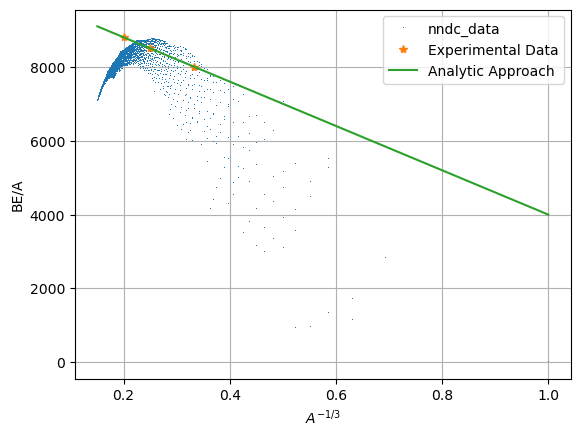

In [ ]:
'''Given Data'''
x_ = bindingEnergy_df['x']
y_ = bindingEnergy_df['bindingEnergy']

xx = np.array([1.0/3, 1.0/4, 1.0/5])
yy = np.array([8000, 8500, 8800])

start = bindingEnergy_df.x[0]
end = bindingEnergy_df.x[6343]
xxx = np.linspace(start, end, 294)
yyy = -xp[0]*xxx + xp[1] # Analytic Approach 

plt.plot(x_, y_, ',', label = 'nndc_data')
plt.plot(xx, yy, '*', label = 'Experimental Data')
plt.plot(xxx, yyy, label = 'Analytic Approach')
plt.legend()
plt.grid()
plt.xlabel(r'$A^{-1/3}$') # Writes like in LaTeX
plt.ylabel('BE/A')
plt.show()